In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import sunpy.map

import scipy.io as sio
from scipy.io import readsav

from astropy.time import Time
from astropy.io import fits

import astropy.units as u


In [16]:
path = '/home/sophie-stucki/starsim/starsim/SDO_input/maps_lily_satire/'

sdo_example = '/home/sophie-stucki/starsim/starsim/SDO_input/SDO_images/hmi.ic_nolimbdark_720s.20170831_000000_TAI.3.continuum.fits'

los_fits = fits.open(sdo_example)
los_map = sunpy.map.Map(los_fits[1].data, los_fits[1].header, sequence=True, allow_errors=True)

In [17]:
B_sat = 305

out_shape = (1024, 1024)

los_map = los_map[0].resample(out_shape * u.pix)   


min_p = np.int32(np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/maps_lily/min_p.txt'))
max_p = np.int32(np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/maps_lily/max_p.txt'))


/home/sophie-stucki/starsim/starsim/SDO_input/maps_lily_satire/2021.04.27_00_00_00_TAI_bmu_mask.sav
/home/sophie-stucki/starsim/starsim/SDO_input/maps_lily_satire/2021.04.28_00_00_00_TAI_bmu_mask.sav
/home/sophie-stucki/starsim/starsim/SDO_input/maps_lily_satire/2021.04.29_00_00_00_TAI_bmu_mask.sav
pass
/home/sophie-stucki/starsim/starsim/SDO_input/maps_lily_satire/2021.04.30_00_00_00_TAI_bmu_mask.sav
/home/sophie-stucki/starsim/starsim/SDO_input/maps_lily_satire/2021.05.01_00_00_00_TAI_bmu_mask.sav
/home/sophie-stucki/starsim/starsim/SDO_input/maps_lily_satire/2021.05.02_00_00_00_TAI_bmu_mask.sav
/home/sophie-stucki/starsim/starsim/SDO_input/maps_lily_satire/2021.05.03_00_00_00_TAI_bmu_mask.sav
pass
/home/sophie-stucki/starsim/starsim/SDO_input/maps_lily_satire/2021.05.04_00_00_00_TAI_bmu_mask.sav
pass
/home/sophie-stucki/starsim/starsim/SDO_input/maps_lily_satire/2021.05.05_00_00_00_TAI_bmu_mask.sav
/home/sophie-stucki/starsim/starsim/SDO_input/maps_lily_satire/2021.05.06_00_00_00_TA

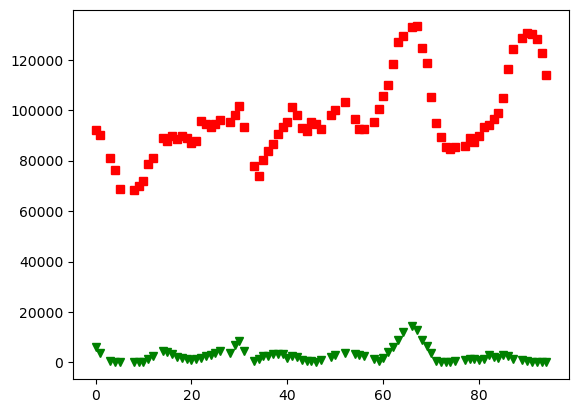

In [18]:
start_date = Time('2021-04-27T00:00:00', format='isot')

nbr_days = 95

day_list = []

for i in range(nbr_days):
    date = str(start_date + i).replace('T00:00:00.000', '').replace('-', '.')
    file = path + date + '_00_00_00_TAI_bmu_mask.sav'
    print(file)
    try:
        distr = sio.readsav(file)
        fac_mask = np.where(distr.fac_bmu_mask >= B_sat,1,distr.fac_bmu_mask/B_sat)
        umb_mask, pen_mask= distr.umb_mask,distr.pen_mask 
        plt.plot(i, np.sum(fac_mask), 'sr')
        plt.plot(i, np.sum(umb_mask+pen_mask), 'vg')

        
        facula_map = np.copy(fac_mask[0:-1:4,0:-1:4])
        facula_map = facula_map[min_p[i]:max_p[i], min_p[i]:max_p[i]]
        facula_map[np.isnan(los_map.data[min_p[i]:max_p[i], min_p[i]:max_p[i]])] = np.nan

        spot_map = np.copy(np.float16((umb_mask+pen_mask)[0:-1:4,0:-1:4]))
        spot_map = spot_map[min_p[i]:max_p[i], min_p[i]:max_p[i]]
        spot_map[np.isnan(los_map.data[min_p[i]:max_p[i], min_p[i]:max_p[i]])] = np.nan



        np.savetxt(path+'faculae_map_{:.1f}.txt'.format(i), facula_map)
        np.savetxt(path+'spot_map_{:.1f}.txt'.format(i), spot_map)
        day_list.append(i)
    except:
        print('pass')
        pass

np.savetxt(path+'time.txt', day_list)

In [ ]:
path = '/home/sophie-stucki/starsim/starsim/SDO_input/maps_mixed/'
nbr_days = 62

for i in range(nbr_days):
    try:
        facula_map_i = np.loadtxt(path+'faculae_map_{:.1f}.txt'.format(i))
        spot_map_i = np.loadtxt(path+'spot_map_{:.1f}.txt'.format(i))
        # plt.imshow(spot_map_i)
        # plt.show()
        
        
    except:
        print(i)
        pass

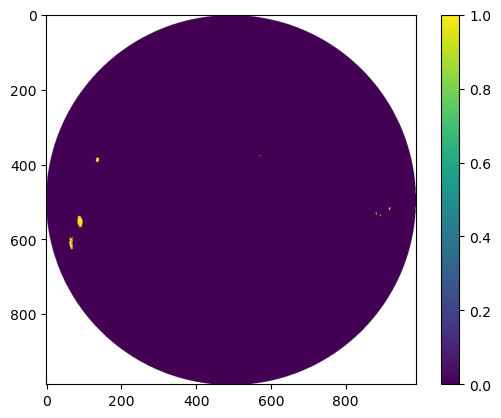

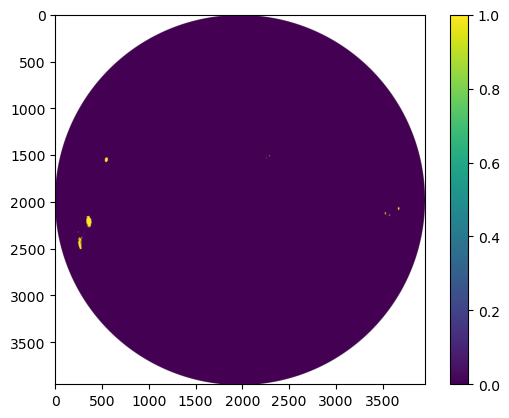

In [ ]:
plt.imshow(spot_map[0:-1:4,0:-1:4])
plt.colorbar()
plt.show()
plt.imshow(spot_map)
plt.colorbar()

0
(936, 936)


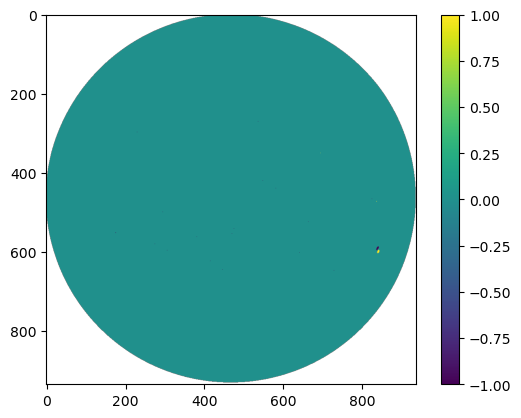

1
(936, 936)


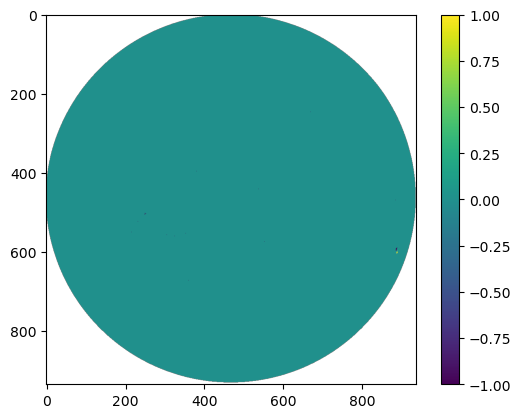

2
(936, 936)


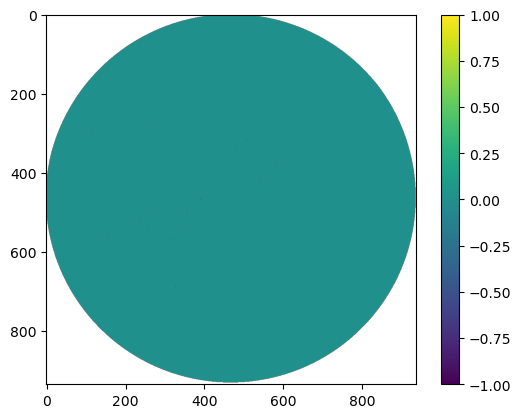

3
(936, 936)


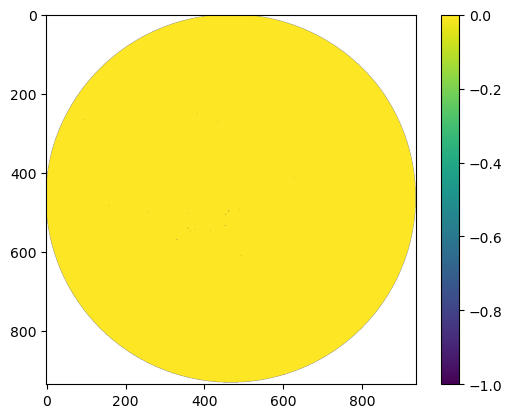

4
(936, 936)


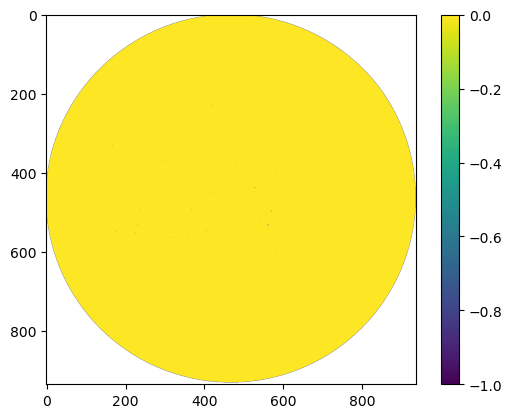

5
(936, 936)


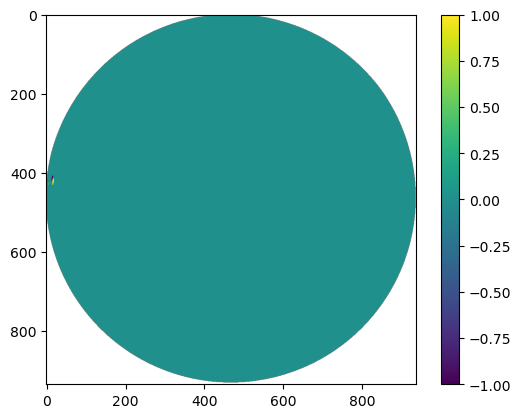

6
(936, 936)


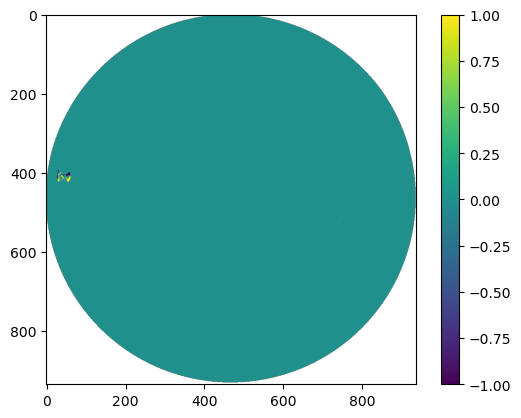

7
(936, 936)


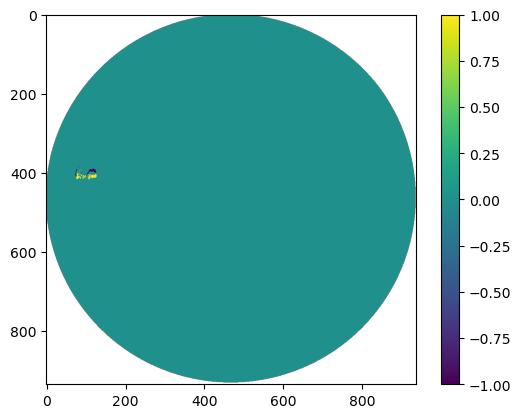

8
(936, 936)


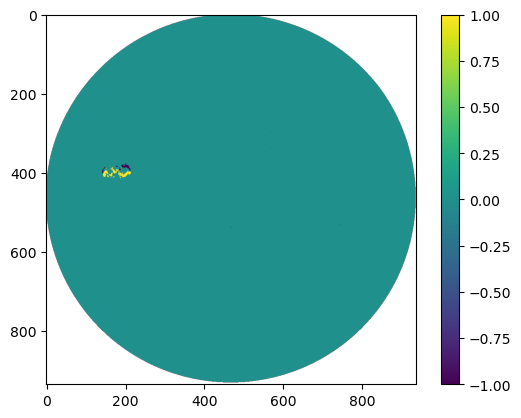

9
(936, 936)


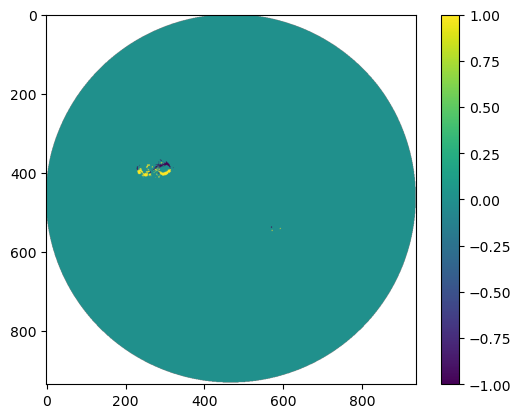

10
(936, 936)


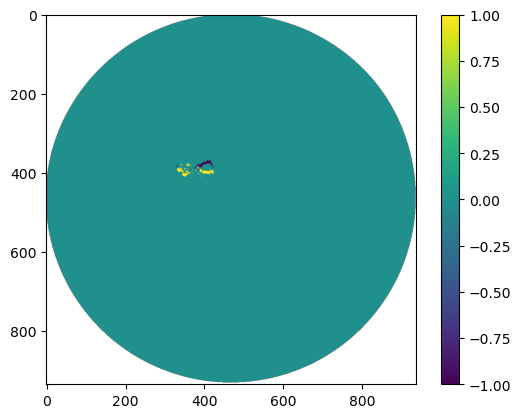

11
(936, 936)


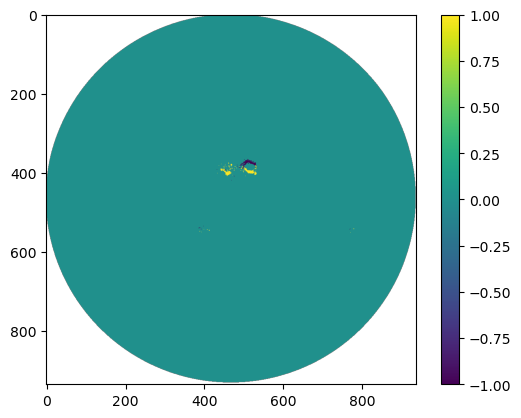

12
(936, 936)


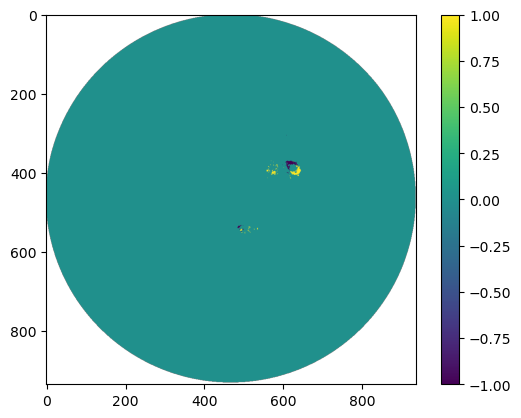

13
(936, 936)


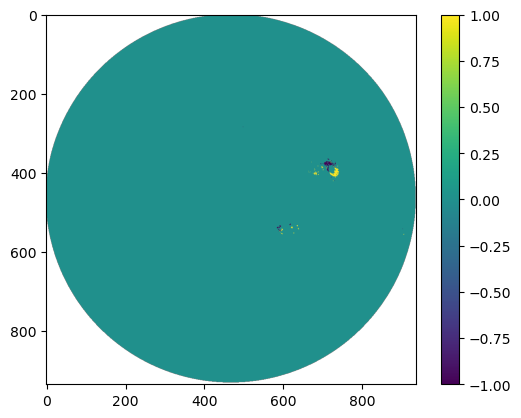

14
(936, 936)


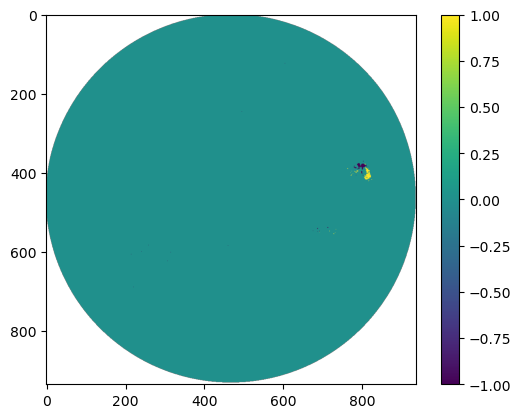

15
(936, 936)


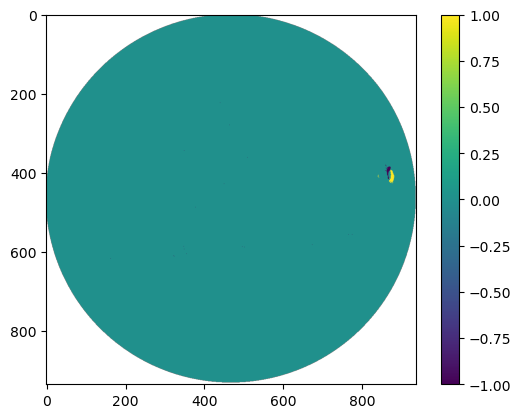

16
(937, 937)


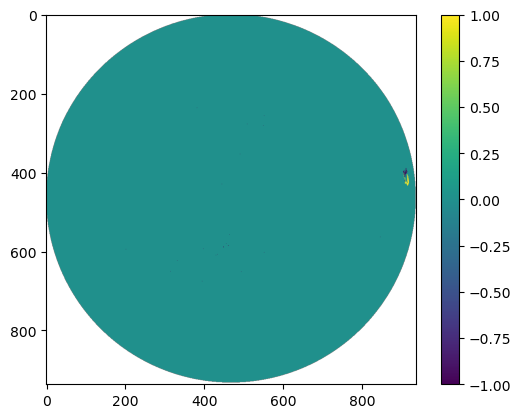

17
(937, 937)


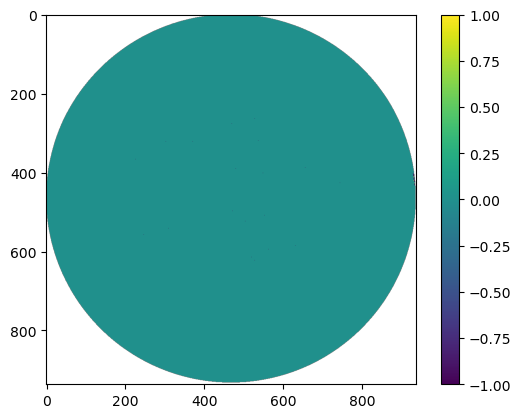

18
(937, 937)


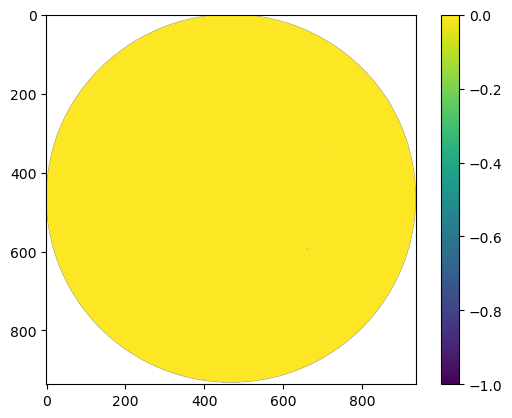

19
(937, 937)


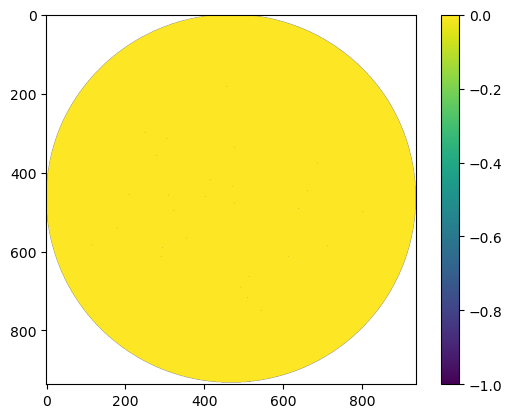

20
(938, 938)


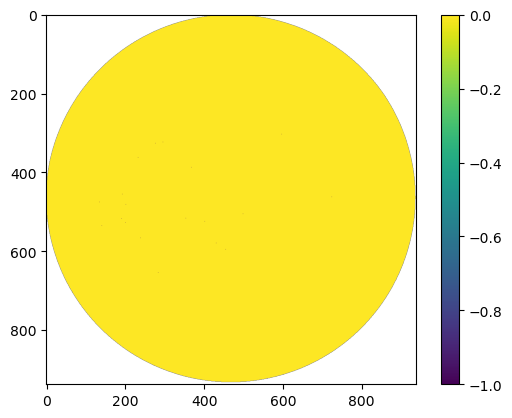

21
(938, 938)


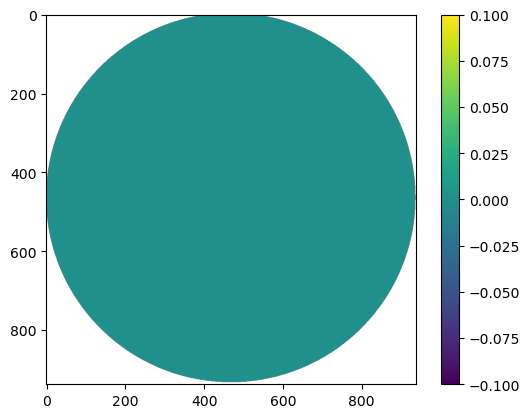

22
(938, 938)


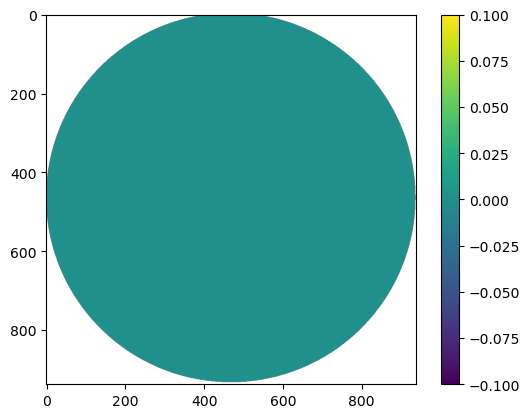

23
(938, 938)


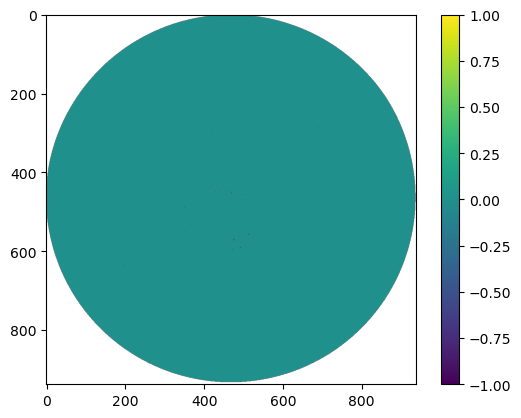

24
(938, 938)


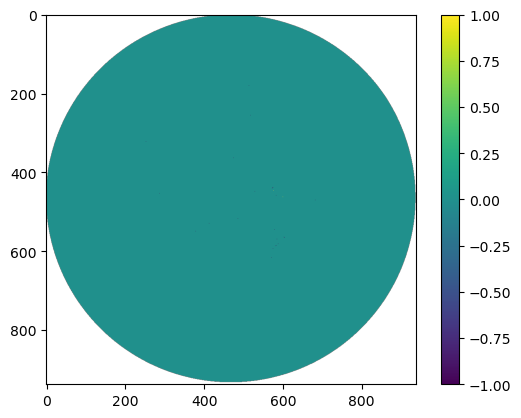

25
(938, 938)


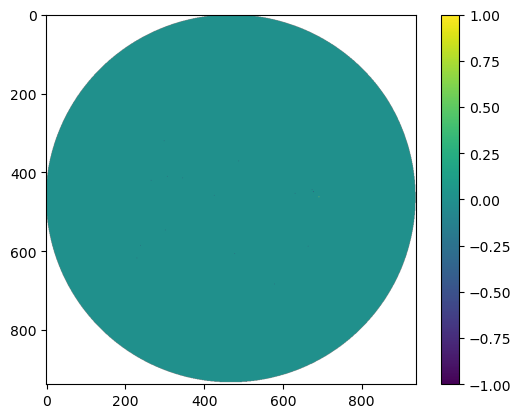

26
(938, 938)


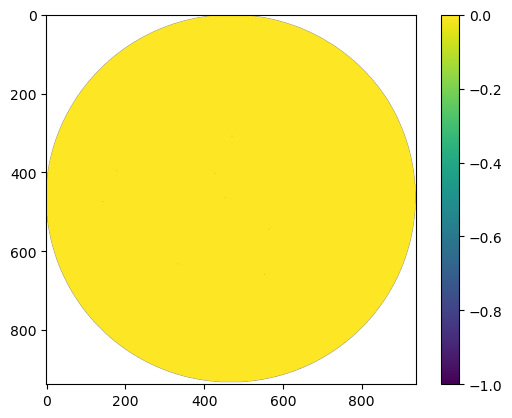

27
(938, 938)


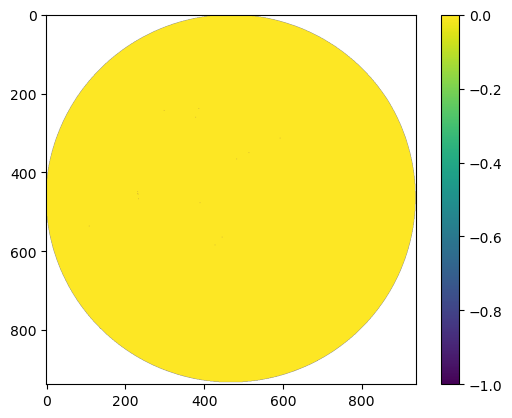

28
(938, 938)


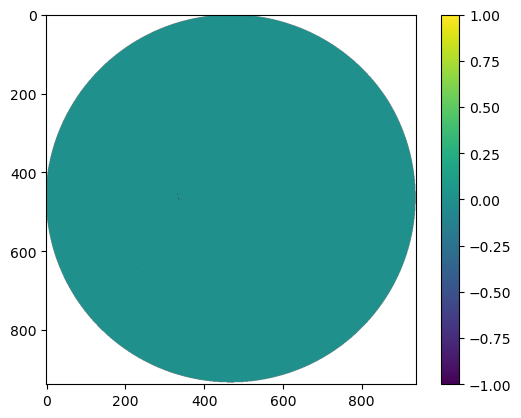

29
(938, 938)


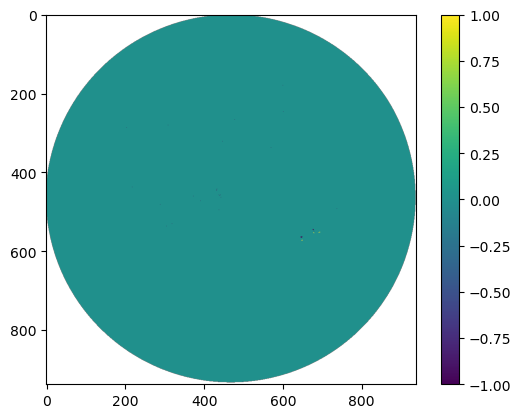

30
(938, 938)


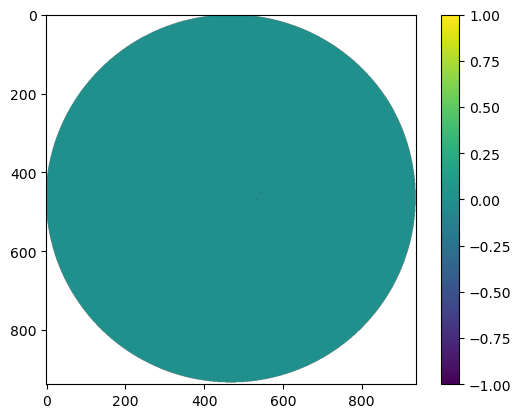

31
(938, 938)


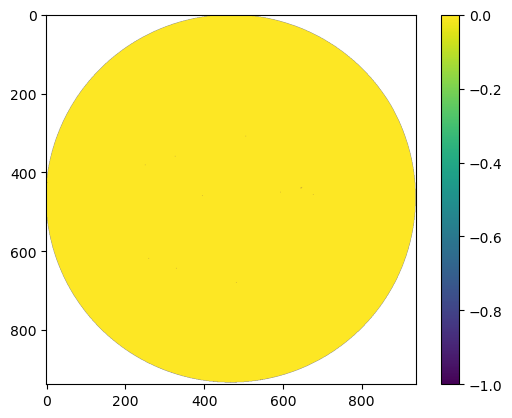

32
(938, 938)


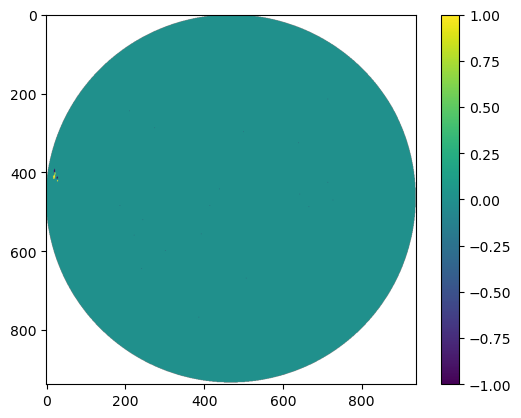

33
(938, 938)


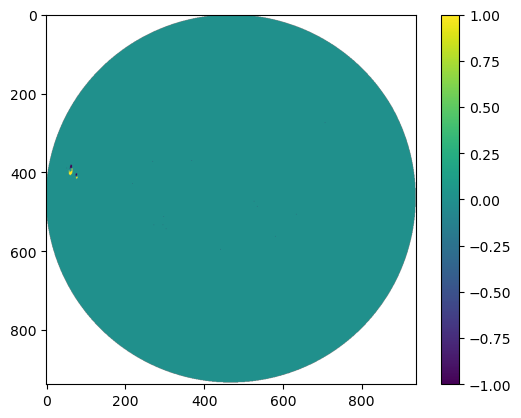

34
(938, 938)


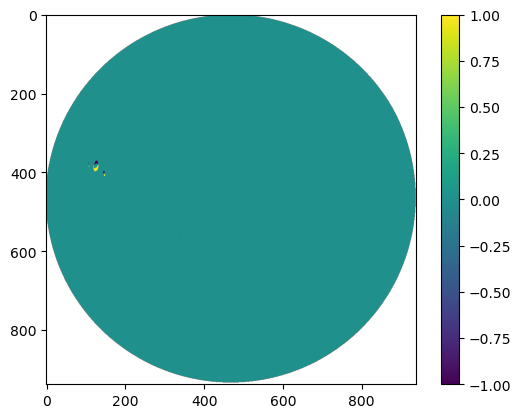

35
(938, 938)


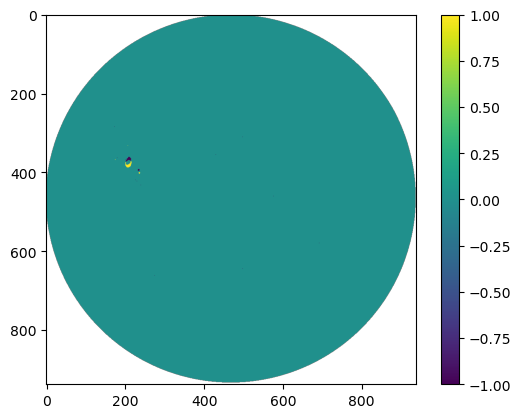

36
(939, 939)


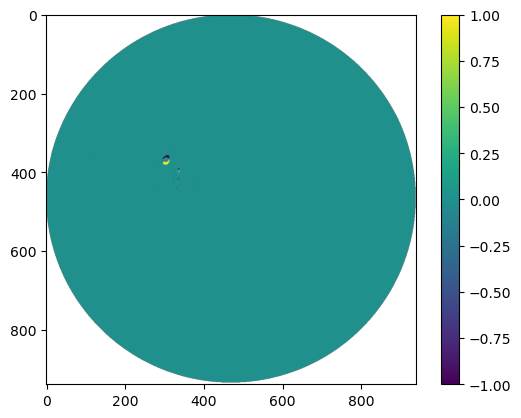

37
(939, 939)


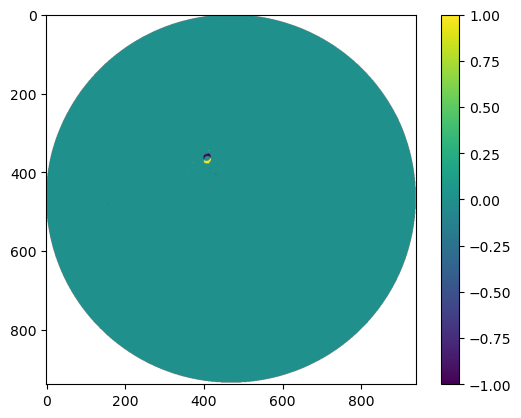

38
(939, 939)


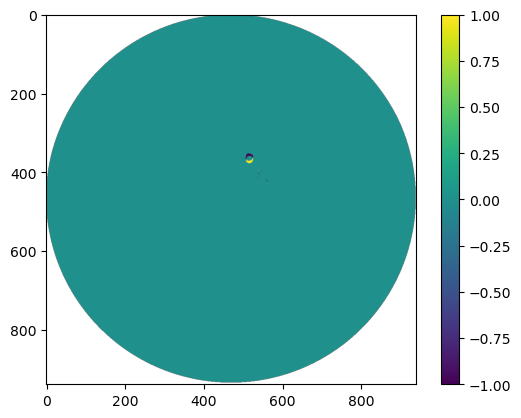

39
(939, 939)


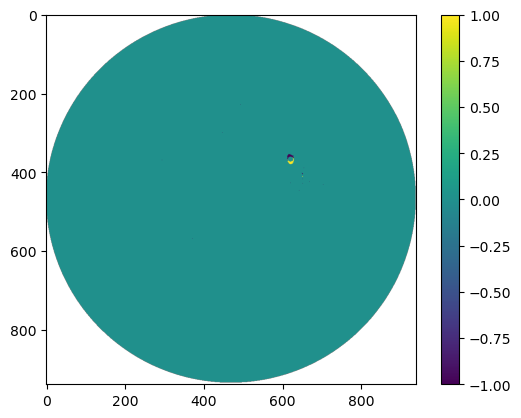

40
(940, 940)


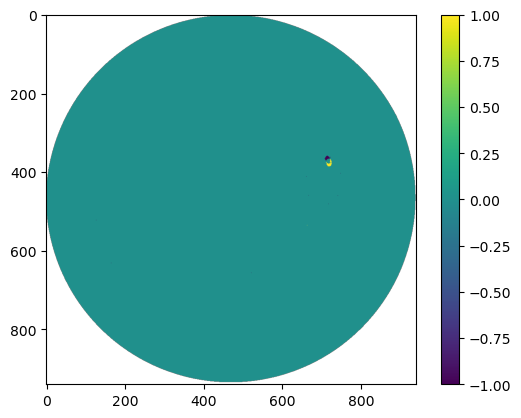

41
(940, 940)


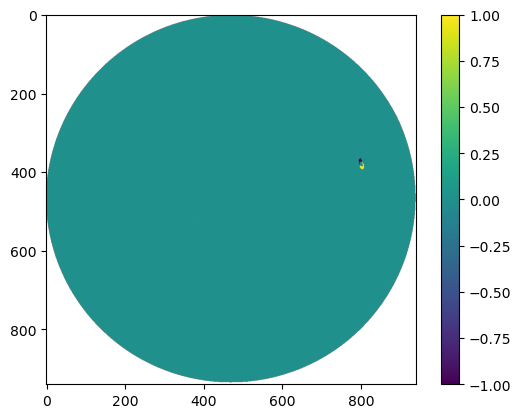

42
(940, 940)


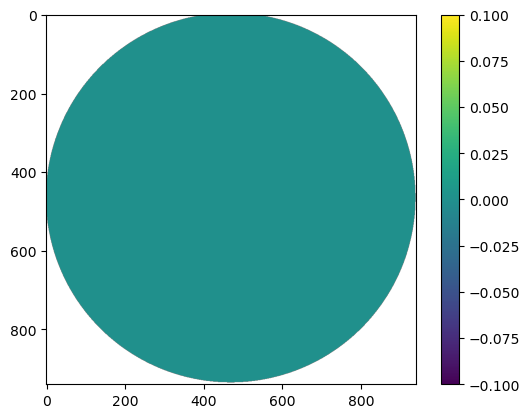

43
(940, 940)


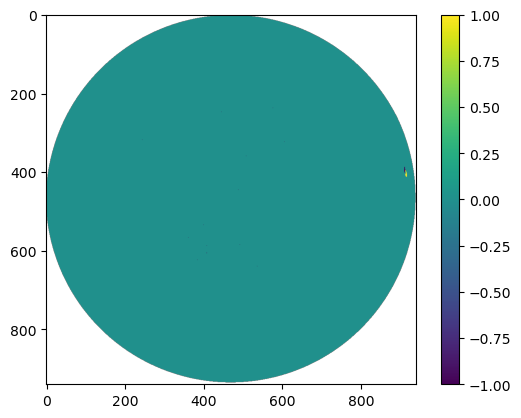

44
(940, 940)


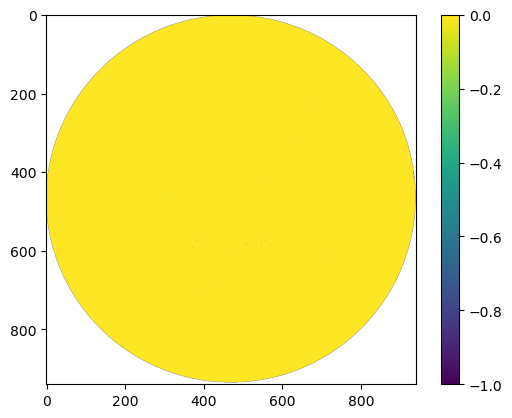

45
(940, 940)


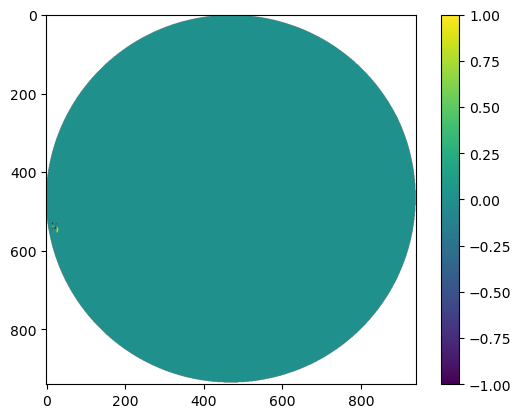

46
(940, 940)


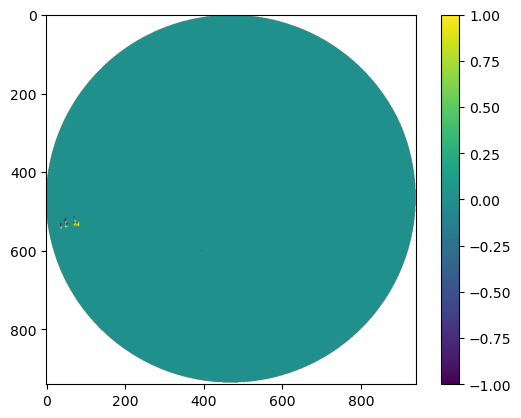

47
(940, 940)


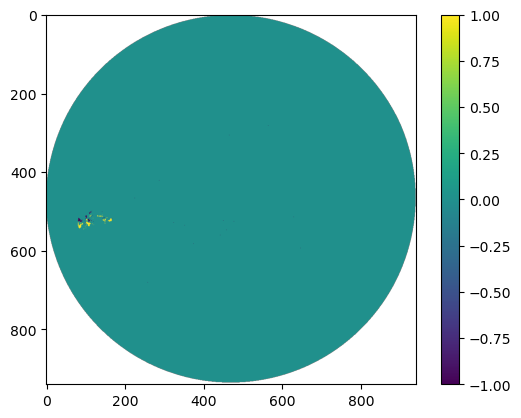

48
(941, 941)


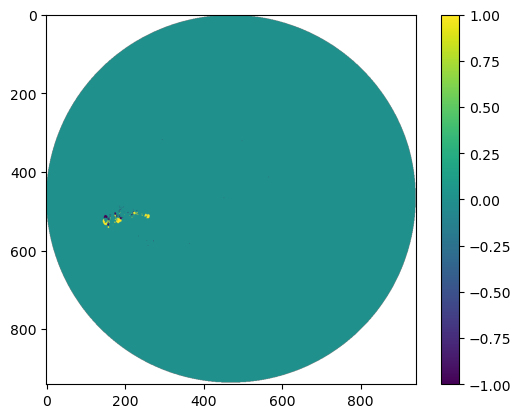

49
(941, 941)


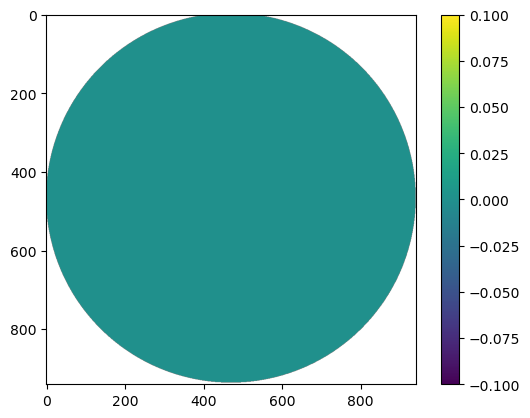

50
(941, 941)


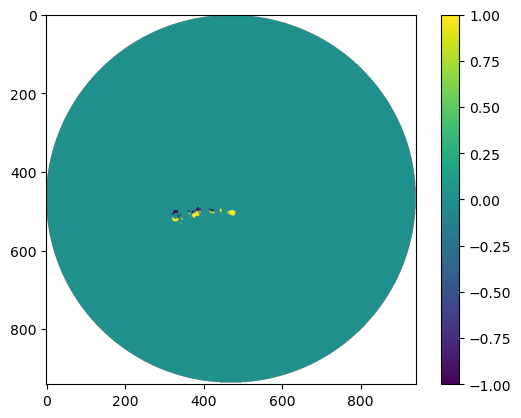

51
(941, 941)


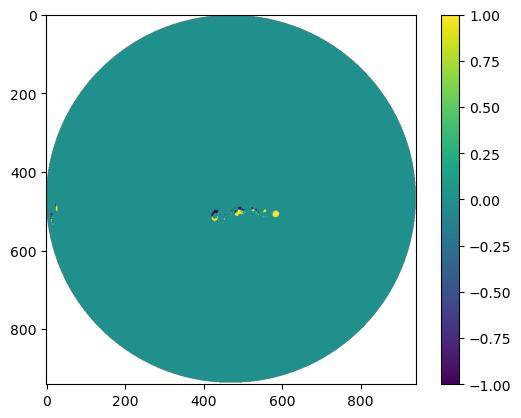

52
(941, 941)


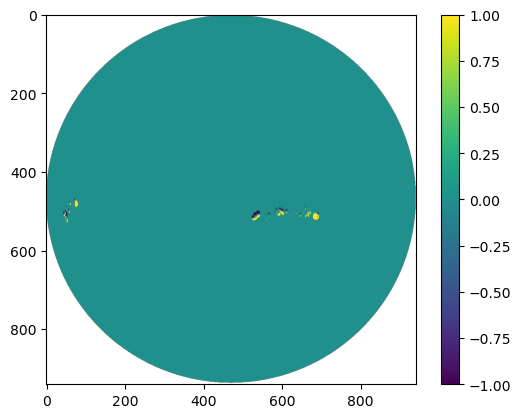

53
(942, 942)


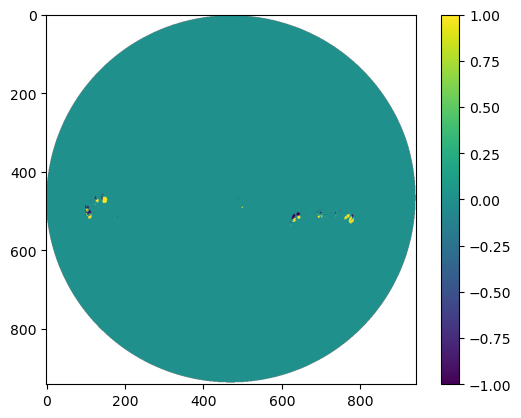

54
(942, 942)


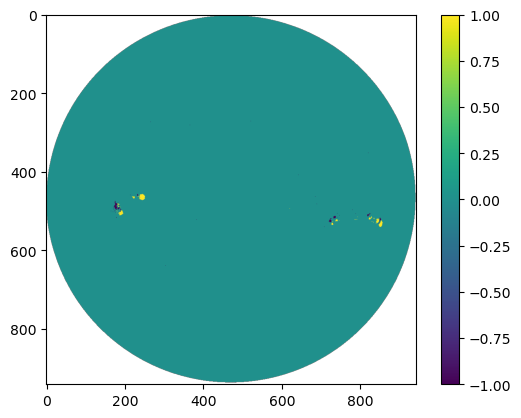

55
(942, 942)


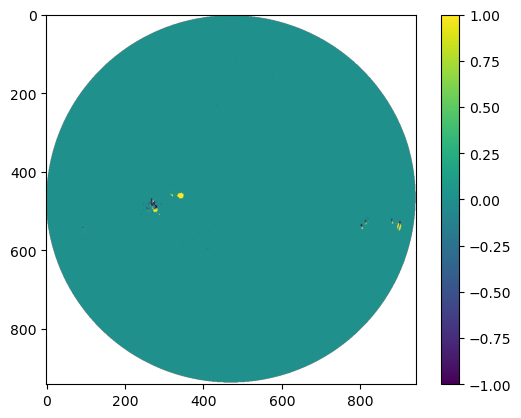

56
(942, 942)


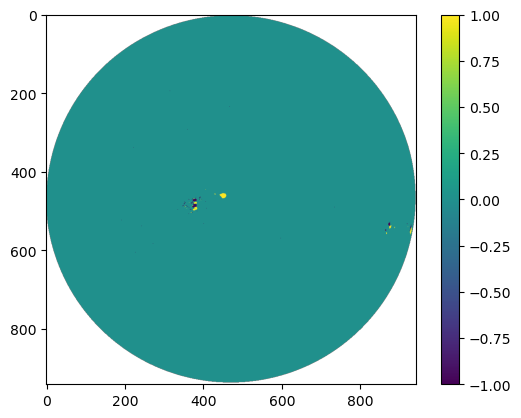

57
(942, 942)


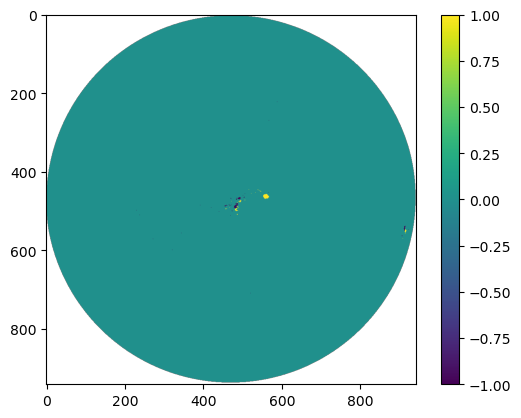

58
(943, 943)


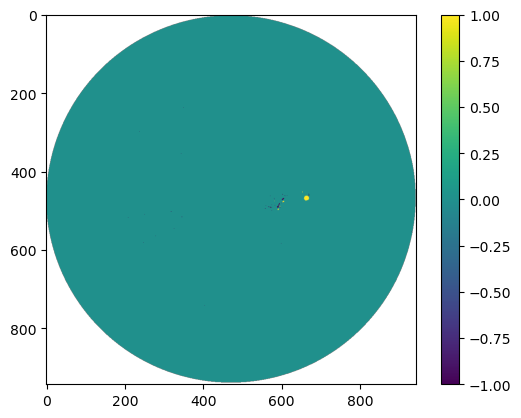

59
(943, 943)


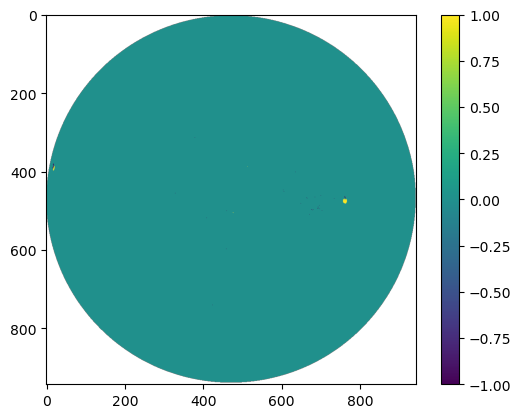

60
(943, 943)


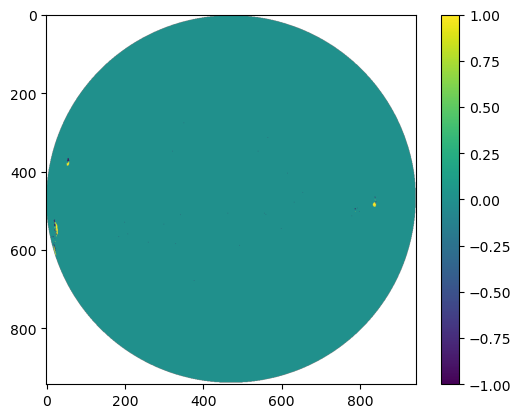

61
(943, 943)


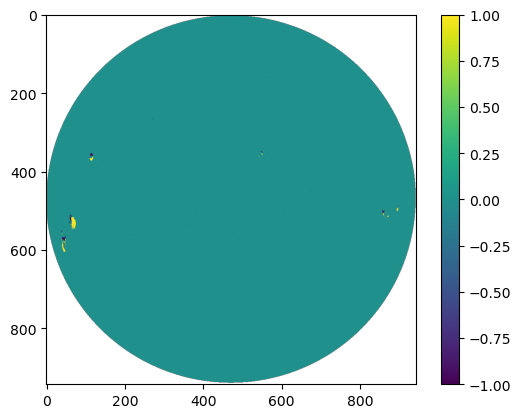

In [ ]:
path_1 = '/home/sophie-stucki/starsim/starsim/SDO_input/maps_mix/'
path_2 = '/home/sophie-stucki/starsim/starsim/SDO_input/maps_I_th_test/'

for i in range(62):
    print(i)
    facula_map = np.loadtxt(path_1+'faculae_map_{:.1f}.txt'.format(i))
    print(np.shape(facula_map))
    spot_map_i = np.loadtxt(path_1+'spot_map_{:.1f}.txt'.format(i))
    spot_map_i_2 = np.loadtxt(path_2+'spot_map_{:.1f}.txt'.format(i))


    plt.imshow(spot_map_i-spot_map_i_2,)
    plt.colorbar()
    plt.show()

In [ ]:
spot_map_i.dtype

dtype('float64')

In [ ]:
spot_map_i_2.dtype

dtype('float64')